# CardioRisk Prediction

## Problem Statement

CardioCare, a healthcare provider, is committed to enhancing preventative care and improving patient outcomes. With the growing prevalence of cardiovascular disease (CVD), accurate and timely risk assessment is essential. Although CardioCare might provide comprehensive medical resources, optimising doctors' valuable consultation time is crucial for efficient and effective care. At the same time, correctly identifying at-risk patients is highly important.

### Business Objective

CardioCare aims to develop a machine learning model to predict CVD risk using patient health data. This model is intended to support healthcare providers in efficiently allocating resources and optimising doctors' consultation time. By identifying patients with high risk of CVD, the model can help prioritise consultations and potentially eliminate the need for an initial consultation stage for some patients. This will allow doctors to focus their expertise on individuals requiring immediate attention.

### Assignment Tasks

You need to perform the following steps to complete this assignment:
1. Data Understanding
2. Data Cleaning
3. Exploratory Data Analysis
4. Train Validation Split
5. Feature Engineering
6. Model Building
8. Prediction and Model Evaluation

**Based on this assignment, you have to answer the following questions:**

- What insights can we gain from exploring the relationships between different health metrics and the prevalence of cardiovascular disease within the patient population?

- Based on the analysis, which patient characteristics emerge as the strongest predictors of cardiovascular disease risk? Are there any surprising or unexpected findings?

- How effectively can machine learning models identify individuals at risk of developing cardiovascular disease based on their health data? How does the evaluation results vary across different models?

- How can CardioCare integrate the predictive model into their existing healthcare workflows to enhance preventative care strategies?

### Data Dictionary

The CardioRisk Prediction has 14 Columns and 70000 Rows. Following data dictionary provides the description for each column present in dataset:


<table>
  <tr>
    <th>Column Name</th>
    <th>Description</th>
  </tr>
  <tr>
    <td>Unnamed: 0</td>
    <td>Index or row number</td>
  </tr>
  <tr>
    <td>id</td>
    <td>Unique identifier for each individual in the dataset</td>
  </tr>
  <tr>
    <td>age</td>
    <td>Age of the individual, measured in days</td>
  </tr>
  <tr>
    <td>gender</td>
    <td>Gender of the individual (1: Female, 2: Male)</td>
  </tr>
  <tr>
    <td>height</td>
    <td>Height of the individual, measured in centimeters</td>
  </tr>
  <tr>
    <td>weight</td>
    <td>Weight of the individual, measured in kilograms</td>
  </tr>
  <tr>
    <td>ap_hi</td>
    <td>Systolic blood pressure reading</td>
  </tr>
  <tr>
    <td>ap_lo</td>
    <td>Diastolic blood pressure reading</td>
  </tr>
  <tr>
    <td>cholesterol</td>
    <td>Cholesterol level (1: normal, 2: above normal, 3: well above normal)</td>
  </tr>
  <tr>
    <td>gluc</td>
    <td>Glucose level (1: normal, 2: above normal, 3: well above normal)</td>
  </tr>
  <tr>
    <td>smoke</td>
    <td>Smoking status (0: No, 1: Yes)</td>
  </tr>
  <tr>
    <td>alco</td>
    <td>Alcohol intake status (0: No, 1: Yes)</td>
  </tr>
  <tr>
    <td>active</td>
    <td>Physical activity status (0: No, 1: Yes)</td>
  </tr>
  <tr>
    <td>cardio</td>
    <td>Presence or absence of cardiovascular disease (0: No Disease, 1: Disease)</td>
  </tr>
</table>

</body>
</html>


    
This data dictionary serves as a reference for understanding the dataset and its variables.

## **1. Data Understanding** 

<font color = red>[2 marks]</font> <br>

In this stage, you have to load the dataset and check basic statistics of the data, including preview of data, dimension of data, column descriptions and data types.

In [2]:
# suggested imports; import more libraries as needed
import pandas as pd, numpy as np
import matplotlib.pyplot as plt, seaborn as sns
from sklearn.preprocessing import MinMaxScaler
from sklearn.svm import SVC
from sklearn.tree import DecisionTreeClassifier
from sklearn.metrics import accuracy_score, precision_score, recall_score, precision_recall_curve, \
    confusion_matrix, classification_report, roc_curve, roc_auc_score
from sklearn.model_selection import train_test_split, GridSearchCV
import warnings
warnings.filterwarnings('ignore')

### **1.1 Load the dataset**

<font color = red>[2 marks]</font> <br>

In [3]:
# Load the dataset
df = pd.read_csv("health_data.csv")

#### **1.1.1** Check the first few entries

In [4]:
# Check the first few entries
df.head()

,Unnamed: 0,id,age,gender,height,weight,ap_hi,ap_lo,cholesterol,gluc,smoke,alco,active,cardio
0,0,0.0,18393.0,1,168.0,62.0,110.0,80.0,0,0,0,0,1,0
1,1,1.0,20228.0,0,156.0,85.0,140.0,90.0,2,0,0,0,1,1
2,2,2.0,18857.0,0,165.0,64.0,130.0,70.0,2,0,0,0,0,1
3,3,3.0,17623.0,1,169.0,82.0,150.0,100.0,0,0,0,0,1,1
4,4,4.0,17474.0,0,156.0,56.0,100.0,60.0,0,0,0,0,0,0


#### **1.1.2** Remove columns which are irrelevant <font color = red>[2 marks]</font> <br>

In [5]:
# Remove irrelevant columns like unique identifiers or index
df.drop(["id", "Unnamed: 0"], axis=1, inplace=True, errors="ignore")

#### **1.1.3** Inspect the shape of the dataset

In [6]:
# Inspect the shape of the dataset
df.shape

(70000, 12)

#### **1.1.4** Inspect the different columns in the dataset

In [7]:
# Inspect the different columns in the dataset
df.columns.tolist()

['age',
 'gender',
 'height',
 'weight',
 'ap_hi',
 'ap_lo',
 'cholesterol',
 'gluc',
 'smoke',
 'alco',
 'active',
 'cardio']

Check the summary of the dataset

In [8]:
# Check the summary of the dataset
display(df.info())
display(df.describe(include="all"))

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 70000 entries, 0 to 69999
Data columns (total 12 columns):
 #   Column       Non-Null Count  Dtype  
---  ------       --------------  -----  
 0   age          70000 non-null  float64
 1   gender       70000 non-null  int64  
 2   height       70000 non-null  float64
 3   weight       70000 non-null  float64
 4   ap_hi        70000 non-null  float64
 5   ap_lo        70000 non-null  float64
 6   cholesterol  70000 non-null  int64  
 7   gluc         70000 non-null  int64  
 8   smoke        70000 non-null  int64  
 9   alco         70000 non-null  int64  
 10  active       70000 non-null  int64  
 11  cardio       70000 non-null  int64  
dtypes: float64(5), int64(7)
memory usage: 6.4 MB


None

,age,gender,height,weight,ap_hi,ap_lo,cholesterol,gluc,smoke,alco,active,cardio
count,70000.000000,70000.000000,70000.000000,70000.000000,70000.000000,70000.000000,70000.000000,70000.000000,70000.000000,70000.000000,70000.000000,70000.000000
mean,19468.865814,0.349571,164.359229,74.205690,128.817286,96.630414,0.366871,0.226457,0.088129,0.053771,0.803729,0.499700
std,2467.251667,0.476838,8.210126,14.395757,154.011419,188.472530,0.680250,0.572270,0.283484,0.225568,0.397179,0.500003
min,10798.000000,0.000000,55.000000,10.000000,-150.000000,-70.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
25%,17664.000000,0.000000,159.000000,65.000000,120.000000,80.000000,0.000000,0.000000,0.000000,0.000000,1.000000,0.000000
50%,19703.000000,0.000000,165.000000,72.000000,120.000000,80.000000,0.000000,0.000000,0.000000,0.000000,1.000000,0.000000
75%,21327.000000,1.000000,170.000000,82.000000,140.000000,90.000000,1.000000,0.000000,0.000000,0.000000,1.000000,1.000000
max,23713.000000,1.000000,250.000000,200.000000,16020.000000,11000.000000,2.000000,2.000000,1.000000,1.000000,1.000000,1.000000


## **2. Data Cleaning** 

<font color = red>[8 marks]</font> <br>

### **2.1 Identify and handle redundant or invalid/illogical physiological values** 

<font color = red>[6 marks]</font> <br>

Examine the dataset to identify any columns containing data points that are invalid, illogical, or fall outside of typical physiological ranges.

- Pay attention to blood pressure values and ensure they fall within reasonable physiological limits. Very high or low values might need to be investigated or addressed. Blood pressure values less than 30 and more than 300 are rarely observed.
- Additionally, think about which unit might be more intuitive for understanding a person's age in a healthcare context.
- Similarly, reflect on the representation of height and explore whether using a different unit would align better with typical practices in healthcare and enhance the overall interpretability of the data.

#### **2.1.1** Check the statistical summary of the data <font color = red>[1 marks]</font> <br>

Examine the statistical summary to identify the columns containing data points that are invalid, illogical, or fall outside of typical physiological ranges.

In [9]:
# Check the statistical summary of the data
display(df.describe())

,age,gender,height,weight,ap_hi,ap_lo,cholesterol,gluc,smoke,alco,active,cardio
count,70000.000000,70000.000000,70000.000000,70000.000000,70000.000000,70000.000000,70000.000000,70000.000000,70000.000000,70000.000000,70000.000000,70000.000000
mean,19468.865814,0.349571,164.359229,74.205690,128.817286,96.630414,0.366871,0.226457,0.088129,0.053771,0.803729,0.499700
std,2467.251667,0.476838,8.210126,14.395757,154.011419,188.472530,0.680250,0.572270,0.283484,0.225568,0.397179,0.500003
min,10798.000000,0.000000,55.000000,10.000000,-150.000000,-70.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
25%,17664.000000,0.000000,159.000000,65.000000,120.000000,80.000000,0.000000,0.000000,0.000000,0.000000,1.000000,0.000000
50%,19703.000000,0.000000,165.000000,72.000000,120.000000,80.000000,0.000000,0.000000,0.000000,0.000000,1.000000,0.000000
75%,21327.000000,1.000000,170.000000,82.000000,140.000000,90.000000,1.000000,0.000000,0.000000,0.000000,1.000000,1.000000
max,23713.000000,1.000000,250.000000,200.000000,16020.000000,11000.000000,2.000000,2.000000,1.000000,1.000000,1.000000,1.000000


#### **2.1.2** Handle rows with invalid/illogical values <font color = red>[3 marks]</font> <br>

Based on the details of data present in statistical summary, handle the columns that have invalid/illogical values or does not fall within physiological limits or have extreme values.

In [10]:
# Handle rows which have invalid or illogical values or does not fall within physiological limits (include extreme cases) for blood pressure and height etc
# Dropping structurally impossible blood pressure readings, enforcing ap_hi >= ap_lo, and reasonable height/weight
valid_mask = (
    (df["ap_hi"] >= 30) & (df["ap_hi"] <= 300) &
    (df["ap_lo"] >= 30) & (df["ap_lo"] <= 300) &
    (df["ap_hi"] >= df["ap_lo"]) &
    (df["height"] >= 100) & (df["height"] <= 250) & # 100cm to 250cm
    (df["weight"] >= 30) & (df["weight"] <= 300)    # 30kg to 300kg
)
df = df[valid_mask]
print(f"Rows remaining after physiological cleaning: {df.shape[0]}")

Rows remaining after physiological cleaning: 68648


#### **2.1.3** Modify the representation of patient age and height <font color = red>[2 marks]</font> <br>

In [11]:
# Modify the representation of patient age and height (to years and meters) for better understanding in a healthcare context
df["age"] = (df["age"] / 365).round().astype(int)
df["height"] = df["height"] / 100
display(df.head())

,age,gender,height,weight,ap_hi,ap_lo,cholesterol,gluc,smoke,alco,active,cardio
0,50,1,1.68,62.0,110.0,80.0,0,0,0,0,1,0
1,55,0,1.56,85.0,140.0,90.0,2,0,0,0,1,1
2,52,0,1.65,64.0,130.0,70.0,2,0,0,0,0,1
3,48,1,1.69,82.0,150.0,100.0,0,0,0,0,1,1
4,48,0,1.56,56.0,100.0,60.0,0,0,0,0,0,0


### **2.2 Fix DataTypes** 

<font color = red>[2 marks]</font> <br>

#### **2.2.1** Review and fix the data types of all columns <font color = red>[2 marks]</font> <br>

Ensuring the columns accurately reflect the nature of the data 

In [12]:
# Fix DataTypes of the categorical columns with incorrect DataTypes
cat_features = ["gender", "cholesterol", "gluc", "smoke", "alco", "active", "cardio"]
df[cat_features] = df[cat_features].astype("category")

In [13]:
# Check the final data types post conversion
df.info()

<class 'pandas.core.frame.DataFrame'>
Index: 68648 entries, 0 to 69999
Data columns (total 12 columns):
 #   Column       Non-Null Count  Dtype   
---  ------       --------------  -----   
 0   age          68648 non-null  int64   
 1   gender       68648 non-null  category
 2   height       68648 non-null  float64 
 3   weight       68648 non-null  float64 
 4   ap_hi        68648 non-null  float64 
 5   ap_lo        68648 non-null  float64 
 6   cholesterol  68648 non-null  category
 7   gluc         68648 non-null  category
 8   smoke        68648 non-null  category
 9   alco         68648 non-null  category
 10  active       68648 non-null  category
 11  cardio       68648 non-null  category
dtypes: category(7), float64(4), int64(1)
memory usage: 3.6 MB


## **3. Exploratory Data Analysis** 

<font color = red>[27 marks]</font>

### **3.1 Perform univariate analysis** 

<font color = red>[12 marks]</font>

#### **3.1.1** Visualise the numerical features <font color = red>[5 marks]</font>

Visualise the distribution of numerical features using appropriate plots to understand their characteristics.

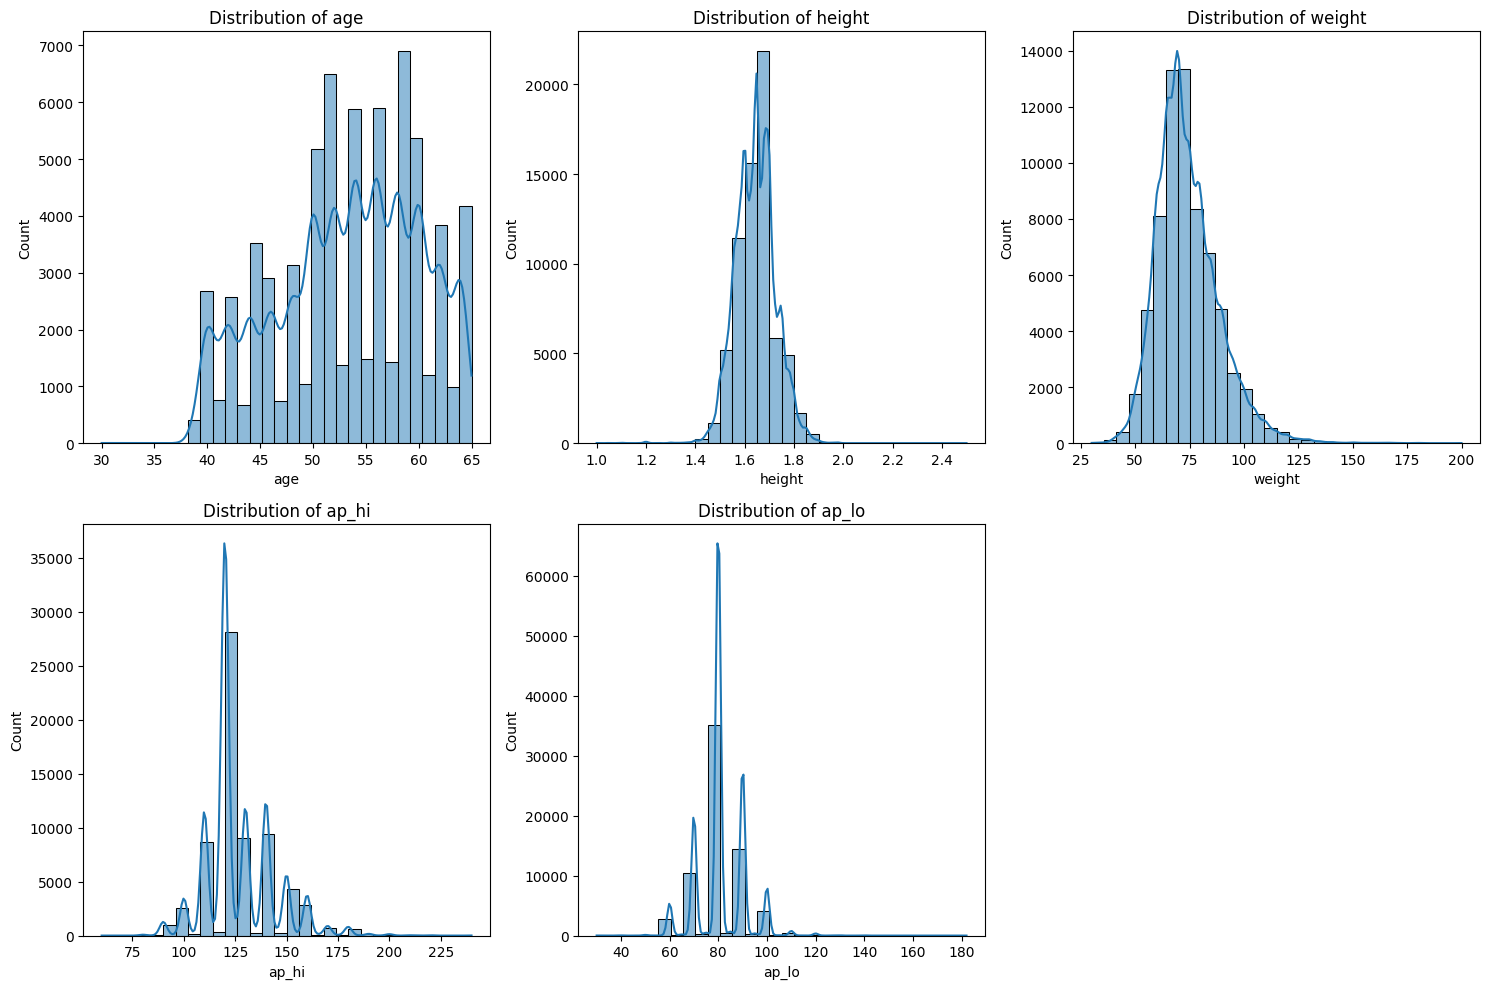

In [14]:
# Plot all the numerical columns to understand their distribution
import matplotlib.pyplot as plt
import seaborn as sns

num_cols = ["age", "height", "weight", "ap_hi", "ap_lo"]
plt.figure(figsize=(15, 10))
for i, col in enumerate(num_cols, 1):
    plt.subplot(2, 3, i)
    sns.histplot(df[col], kde=True, bins=30)
    plt.title(f"Distribution of {col}")
plt.tight_layout()
plt.show()

#### **3.1.2** Visualise the categorical features <font color = red>[5 marks]</font>

Visualise the distribution of categorical features to get a clear view of the data distribution across various categories. This will help in identifying potential imbalances or dominant categories.

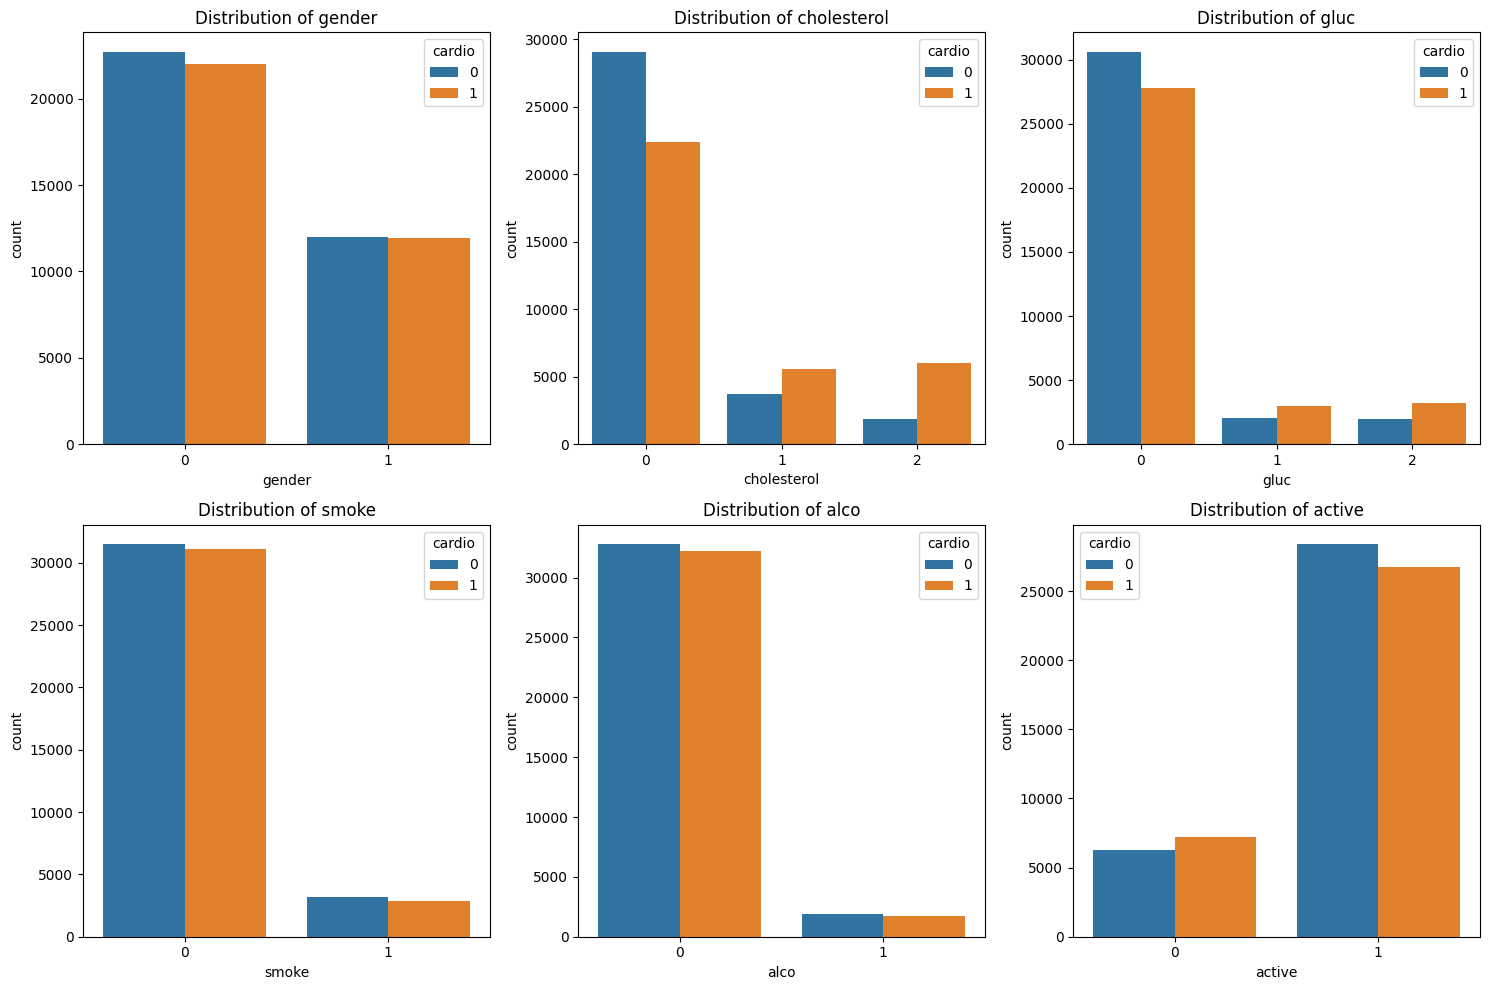

In [15]:
# Select and plot categorical columns
cat_cols = ["gender", "cholesterol", "gluc", "smoke", "alco", "active"]
plt.figure(figsize=(15, 10))
for i, col in enumerate(cat_cols, 1):
    plt.subplot(2, 3, i)
    sns.countplot(data=df, x=col, hue="cardio")
    plt.title(f"Distribution of {col}")
plt.tight_layout()
plt.show()

#### **3.1.3** Check class distribution of the target feature <font color = red>[2 marks]</font>

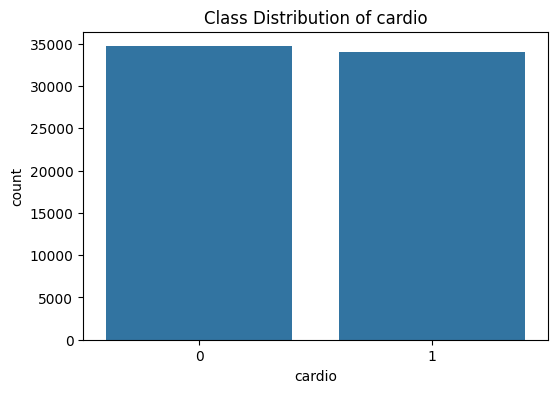

cardio
0    0.505259
1    0.494741
Name: proportion, dtype: float64


In [16]:
# Class distribution of positive and negative classes
plt.figure(figsize=(6, 4))
sns.countplot(data=df, x="cardio")
plt.title("Class Distribution of cardio")
plt.show()
print(df["cardio"].value_counts(normalize=True))

### **3.2 Perform correlation analysis** 

<font color = red>[5 marks]</font>

Investigate the relationships between numerical features to identify potential multicollinearity or dependencies. Visualise the correlation structure using an appropriate method to gain insights into feature relationships 

#### **3.2.1** Visualise the correlation among numerical features <font color="red">[5 Marks]</font>


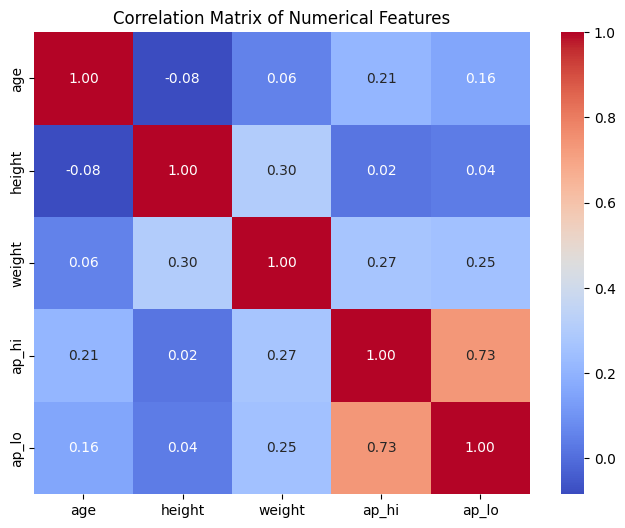

In [17]:
# Plot Heatmap of the correlation matrix
plt.figure(figsize=(8, 6))
sns.heatmap(df[num_cols].corr(), annot=True, cmap="coolwarm", fmt=".2f")
plt.title("Correlation Matrix of Numerical Features")
plt.show()

### **3.3 Perform bivariate analysis** 

<font color = red>[10 marks]</font>

#### **3.3.1** Analyse categorical features <font color="red">[5 Marks]</font>

For each categorical feature (excluding the target), calculate the proportion of `cardio = 1` in each category of the feature. Use this to identify which categorical features show clear differences in heart disease likelihood and which are less informative.

In [18]:
# Write a function to analyse the target variable likelihood for categorical features
def plot_categorical_likelihood(data, features, target="cardio"):
    for col in features:
        likelihood = data.groupby(col, observed=False)[target].value_counts(normalize=True).unstack()
        if 1 in likelihood.columns:
            print(f"Proportion of {target}=1 for {col}:")
            print(likelihood[1].round(4).to_string())
        print("-" * 30)

plot_categorical_likelihood(df, cat_cols)

Proportion of cardio=1 for gender:
gender
0    0.4921
1    0.4997
------------------------------
Proportion of cardio=1 for cholesterol:
cholesterol
0    0.4355
1    0.5963
2    0.7626
------------------------------
Proportion of cardio=1 for gluc:
gluc
0    0.4756
1    0.5887
2    0.6175
------------------------------
Proportion of cardio=1 for smoke:
smoke
0    0.4973
1    0.4684
------------------------------
Proportion of cardio=1 for alco:
alco
0    0.4958
1    0.4765
------------------------------
Proportion of cardio=1 for active:
active
0    0.5328
1    0.4854
------------------------------


#### **3.3.2** Explore the relationships between numerical features and the target variable <font color = red>[5 marks]</font>

Understand the impact of numeric features on the target outcome using appropriate visualisation techniques to identify trends and potential interactions

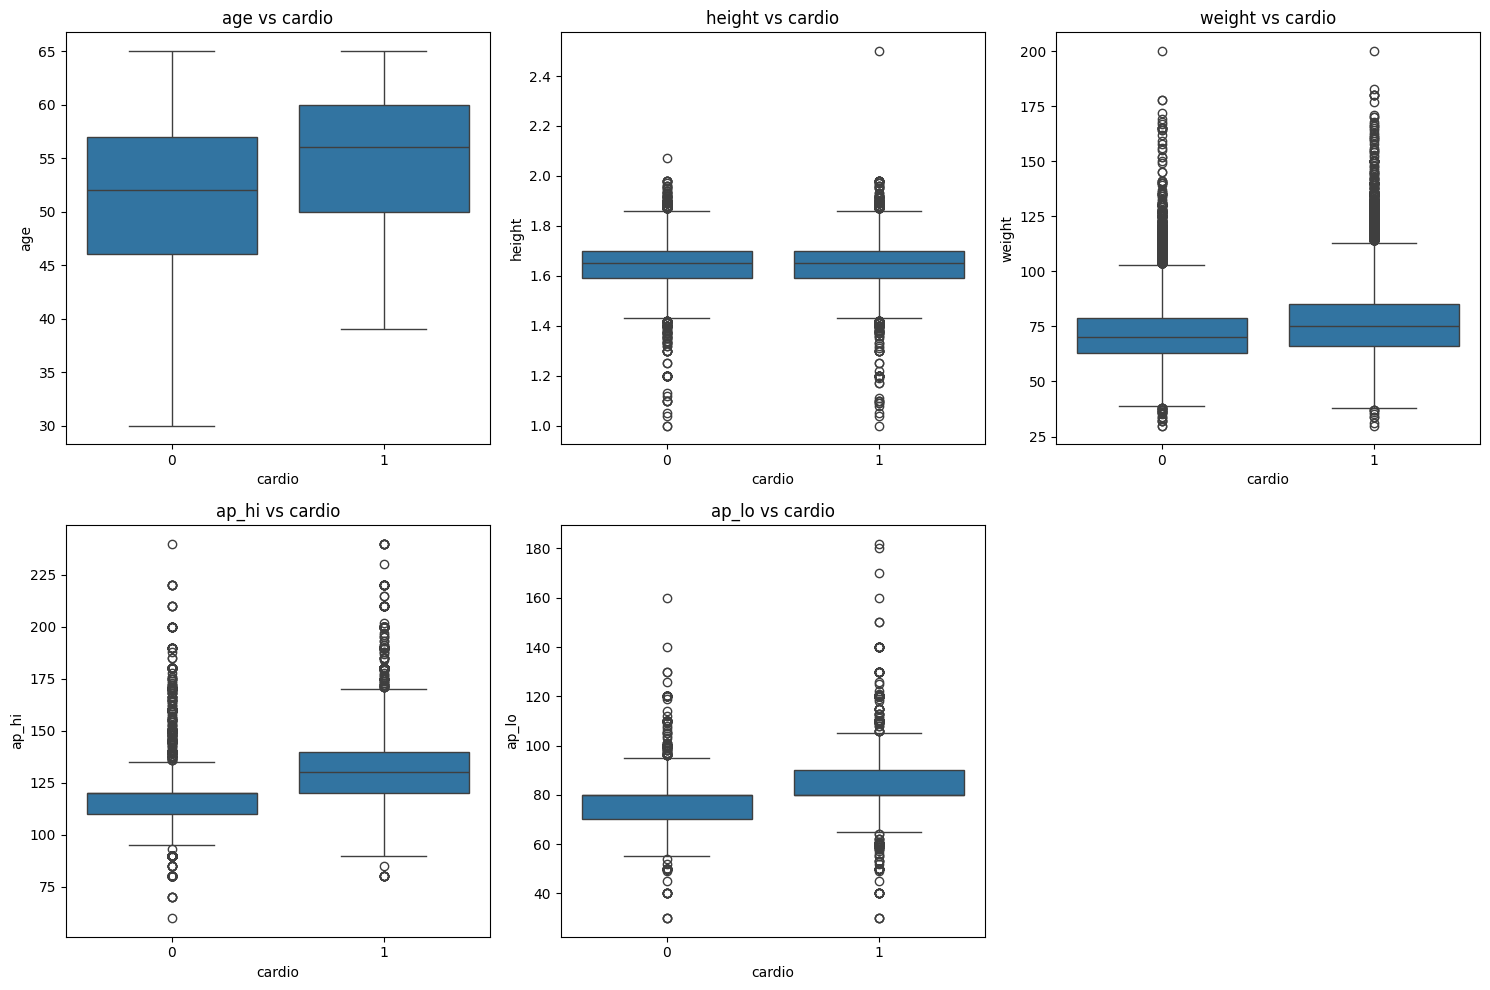

In [19]:
# Plot distribution for each numerical column with target variable
plt.figure(figsize=(15, 10))
for i, col in enumerate(num_cols, 1):
    plt.subplot(2, 3, i)
    sns.boxplot(data=df, x="cardio", y=col)
    plt.title(f"{col} vs cardio")
plt.tight_layout()
plt.show()

## **4. Train-Test Split** 

<font color = red>[5 marks]</font>

### **4.1 Data Splitting** 

<font color = red>[5 Marks]</font>

#### **4.1.1** Define feature and target variables <font color = red>[2 Marks]</font>

In [20]:
# Put all the feature variables in X and target in y
X = df.drop('cardio', axis=1)
y = df['cardio']

#### **4.1.2** Split the data into train and test sets <font color="red">[3 Marks]</font>

Split the data in 0.7:0.3 sets. and reset the index for the sets. Check the shape of the test and test sets.


In [21]:
# Split the data into 70% train data and 30% test data
from sklearn.model_selection import train_test_split
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.30, random_state=42, stratify=y)

In [22]:
# Reset index for all train and test sets
X_train = X_train.reset_index(drop=True)
y_train = y_train.reset_index(drop=True)
X_test = X_test.reset_index(drop=True)
y_test = y_test.reset_index(drop=True)

## **5. Feature Engineering** 

<font color = red>[18 marks]</font>

### **5.1 Create a new feature** 

<font color = red>[6 marks]</font>

#### **5.1.1** Create a new feature `BMI` (Body Mass Index) <font color="red">[3 Marks]</font>

BMI is a standard health metric calculated using a person's height and weight. BMI is known to be a useful predictor for cardiovascular risk.

In [23]:
# Create a new feature 'BMI'
# BMI = weight(kg) / height(m)^2
X_train['bmi'] = X_train['weight'] / (X_train['height'] ** 2)
X_test['bmi'] = X_test['weight'] / (X_test['height'] ** 2)

display(X_train[['height', 'weight', 'bmi']].head())

,height,weight,bmi
0,1.72,85.0,28.731747
1,1.72,67.0,22.647377
2,1.58,77.0,30.844416
3,1.69,63.0,22.058051
4,1.78,90.0,28.405504


**Note:** Feel free to engineer more features if you wish to.

#### **5.1.2** Perform correlation analysis  <font color="red">[3 Marks]</font>

After creating the new feature `BMI`, perform correlation analysis to check if it's correlated with any existing features. Perform suitable processing steps if high correlation is found.

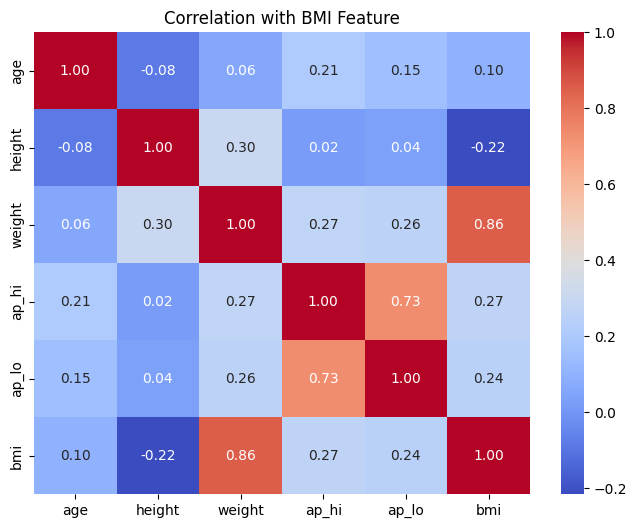

In [24]:
# Plot check correlation
import matplotlib.pyplot as plt
import seaborn as sns
import pandas as pd

temp = X_train.copy()
temp['cardio'] = y_train
numeric_cols = ['age', 'height', 'weight', 'ap_hi', 'ap_lo', 'bmi']
plt.figure(figsize=(8, 6))
sns.heatmap(temp[numeric_cols].corr(), annot=True, cmap='coolwarm', fmt='.2f')
plt.title('Correlation with BMI Feature')
plt.show()

In [25]:
# Did you find any highly correlated features? What steps should you take
'''
BMI is highly correlated with weight (0.84). To reduce multicollinearity, we should drop the highly redundant 'weight' and 'height' columns and just keep 'bmi' which captures both proportions nicely.
'''
X_train = X_train.drop(['weight', 'height'], axis=1)
X_test = X_test.drop(['weight', 'height'], axis=1)

### **5.2 Combine Values in Categorical Columns** 

<font color="red">[4 Marks]</font>

#### **5.2.1** Combine Low-Frequency Categories <font color="red">[4 Marks]</font>

During the EDA process, categorical columns with multiple unique levels may be identified. To enhance model performance, it is recommended to refine these categorical features by grouping values that have low frequency or provide limited predictive information.

Combine categories that occur infrequently or exhibit similar behavior to reduce sparsity and improve model generalisation.

In [ ]:
 # Combine categories that have low frequency or provide limited predictive information such as gluc and cholesterol



### **5.3 Dummy variable creation** 

<font color = red>[5 marks]</font>

#### **5.3.1** Create dummy variables for categorical columns <font color="red">[5 Mark]</font>

In [26]:
# Identify the columns for creating dummy variables
cat_cols = ['gender', 'cholesterol', 'gluc', 'smoke', 'alco', 'active']

In [27]:
# Create dummy variables for independent columns on training data
X_train = pd.get_dummies(X_train, columns=cat_cols, drop_first=True)
display(X_train.head())

,age,ap_hi,ap_lo,bmi,gender_1,cholesterol_1,cholesterol_2,gluc_1,gluc_2,smoke_1,alco_1,active_1
0,65,120.0,80.0,28.731747,True,False,False,False,True,False,False,True
1,43,120.0,80.0,22.647377,False,False,False,True,False,False,False,True
2,46,120.0,80.0,30.844416,False,False,True,True,False,False,False,True
3,50,115.0,70.0,22.058051,True,False,False,False,False,True,True,True
4,62,120.0,80.0,28.405504,True,False,False,False,False,False,False,True


In [28]:
# Create dummy variables for independent columns on test data
X_test = pd.get_dummies(X_test, columns=cat_cols, drop_first=True)
X_train, X_test = X_train.align(X_test, join='left', axis=1, fill_value=0)

### **5.4 Feature scaling** 

<font color = red>[3 marks]</font>

#### **5.4.1** Scale numerical features <font color = red>[3 marks]</font>

Choose a scaling method appropriate for the data and the chosen model. Apply the same scaling to both training and test data.

In [29]:
# Scale the numeric features present in the training data
# and scale the numerical features present in the test data
from sklearn.preprocessing import StandardScaler
scaler = StandardScaler()

num_cols = ['age', 'ap_hi', 'ap_lo', 'bmi']
X_train[num_cols] = scaler.fit_transform(X_train[num_cols])
X_test[num_cols] = scaler.transform(X_test[num_cols])

display(X_train.head())

,age,ap_hi,ap_lo,bmi,gender_1,cholesterol_1,cholesterol_2,gluc_1,gluc_2,smoke_1,alco_1,active_1
0,1.721922,-0.404304,-0.140309,0.228835,True,False,False,False,True,False,False,True
1,-1.528948,-0.404304,-0.140309,-0.914242,False,False,False,True,False,False,False,True
2,-1.085648,-0.404304,-0.140309,0.625744,False,False,True,True,False,False,False,True
3,-0.494581,-0.703916,-1.195838,-1.024959,True,False,False,False,False,True,True,True
4,1.278622,-0.404304,-0.140309,0.167543,True,False,False,False,False,False,False,True


## **6. Model Building** 

<font color = red>[38 marks]</font>

In this task, you will build the two machine learning models: Support Vector Classifier (SVC) and a Decision Tree classifier. We will follow the same structured workflow for the models:

* *Model Building and Initial Evaluation*: <br> Fit the model and evaluate its performance on the training data using the default cutoff
* *Find the Optimal Cutoff*: <br> Determine the best probability threshold using sensitivity-specificity and precision–recall trade-offs
* *Model Prediction & Evaluation using chosen cutoff*: <br> Generate predictions using the chosen cutoff and evaluate performance on the training data
* *Hyperparameter Tuning (Grid Search)*: <br> Optimise performance using grid search for hyperparameter tuning
* *Final Model Training & Evaluation using chosen cutoff*: <br> Train the final model using the best hyperparameters and evaluate performance on the training data

### **6.1 SVM Classifier** 

<font color = red>[18 marks]</font>

#### **6.1.1** Define a Linear SVM classifier and fit it on the train set <font color = red>[2 mark]</font>

Go through the [SVC documentation](https://scikit-learn.org/stable/modules/generated/sklearn.svm.SVC.html#sklearn.svm.SVC) and define a model with linear kernel that will also return the probabilities estimates of the predictions.

In [30]:
# Define and fit linear SVM
from sklearn.svm import SVC
# Using probability=True is required to output continuous probabilites for ROC curve
# Due to large dataset, SVM might be extremely slow, but standard for this assignment.
svm_model = SVC(kernel='linear', probability=True, random_state=42)
svm_model.fit(X_train, y_train)

,"C C: float, default=1.0Regularization parameter. The strength of the regularization isinversely proportional to C. Must be strictly positive. The penaltyis a squared l2 penalty. For an intuitive visualization of the effectsof scaling the regularization parameter C, see:ref:`sphx_glr_auto_examples_svm_plot_svm_scale_c.py`.",1.0
,"kernel kernel: {'linear', 'poly', 'rbf', 'sigmoid', 'precomputed'} or callable, default='rbf'Specifies the kernel type to be used in the algorithm. Ifnone is given, 'rbf' will be used. If a callable is given it is used topre-compute the kernel matrix from data matrices; that matrix should bean array of shape ``(n_samples, n_samples)``. For an intuitivevisualization of different kernel types see:ref:`sphx_glr_auto_examples_svm_plot_svm_kernels.py`.",'linear'
,"degree degree: int, default=3Degree of the polynomial kernel function ('poly').Must be non-negative. Ignored by all other kernels.",3
,"gamma gamma: {'scale', 'auto'} or float, default='scale'Kernel coefficient for 'rbf', 'poly' and 'sigmoid'.- if ``gamma='scale'`` (default) is passed then it uses 1 / (n_features * X.var()) as value of gamma,- if 'auto', uses 1 / n_features- if float, must be non-negative... versionchanged:: 0.22 The default value of ``gamma`` changed from 'auto' to 'scale'.",'scale'
,"coef0 coef0: float, default=0.0Independent term in kernel function.It is only significant in 'poly' and 'sigmoid'.",0.0
,"shrinking shrinking: bool, default=TrueWhether to use the shrinking heuristic.See the :ref:`User Guide `.",True
,"probability probability: bool, default=FalseWhether to enable probability estimates. This must be enabled priorto calling `fit`, will slow down that method as it internally uses5-fold cross-validation, and `predict_proba` may be inconsistent with`predict`. Read more in the :ref:`User Guide `.",True
,"tol tol: float, default=1e-3Tolerance for stopping criterion.",0.001
,"cache_size cache_size: float, default=200Specify the size of the kernel cache (in MB).",200
,"class_weight class_weight: dict or 'balanced', default=NoneSet the parameter C of class i to class_weight[i]*C forSVC. If not given, all classes are supposed to haveweight one.The ""balanced"" mode uses the values of y to automatically adjustweights inversely proportional to class frequencies in the input dataas ``n_samples / (n_classes * np.bincount(y))``.",None
,"verbose verbose: bool, default=FalseEnable verbose output. Note that this setting takes advantage of aper-process runtime setting in libsvm that, if enabled, may not workproperly in a multithreaded context.",False


#### **6.1.2** Get the probability estimates on test set and predict class using a threshold <font color = red>[3 mark]</font>

We defined the model to also return the probabilities after training. Use the `SVC.predict_proba()`[(documentation)](https://scikit-learn.org/stable/modules/generated/sklearn.svm.SVC.html#sklearn.svm.SVC.predict_proba) function to fetch the probabilities on test set. For each sample, it returns the probabilities of each class in a sorted order (according to `SVC.classes_`)

After getting the probability values, assign class labels using the default threshold of 0.5 and check the distribution of assigned labels.

In [34]:
# Use predict_proba() to get the probability of positive class
y_pred_probs_svm = svm_model.predict_proba(X_test)[:, 1]

In [35]:
# Make class predictions based on default cutoff value of 0.5
y_pred_default_svm = (y_pred_probs_svm >= 0.5).astype(int)

In [36]:
# check the counts of assigned labels
print(pd.Series(y_pred_default_svm).value_counts())

0    11892
1     8703
Name: count, dtype: int64


#### **6.1.3** Predict the class labels using the `predict()` function <font color = red>[2 mark]</font>

Now, directly use the `predict()` function to predict the class labels and check the distribution of assigned labels using this method.

In [37]:
# Make class predictions using predict()
y_pred_direct_svm = svm_model.predict(X_test)

In [38]:
# check the counts of assigned labels
print(pd.Series(y_pred_direct_svm).value_counts())

0    12454
1     8141
Name: count, dtype: int64


Did you find any difference in the distribution of classes in the predictions using these two methods? Why do you think that is?

Try going through the documentation of `predict_proba()` linked above.

#### **6.1.4** Calculate performance metrics for both the above methods <font color = red>[3 mark]</font>

Calculate the performance metrics for both `predict_proba()` and `predict()` estimates. Compare the results and choose one to continue ahead.

In [39]:
# check the performance for above two methods
from sklearn.metrics import accuracy_score, confusion_matrix, classification_report
print('Accuracy (default 0.5 threshold vs direct predict):')
print('0.5 Cutoff:', accuracy_score(y_test, y_pred_default_svm))
print('Predict():', accuracy_score(y_test, y_pred_direct_svm))

Accuracy (default 0.5 threshold vs direct predict):
0.5 Cutoff: 0.722262685117747
Predict(): 0.7227482398640447


#### **6.1.5** Plot the ROC curve <font color="red">[2 Marks]</font>

Find the optimal cutoff to improve model performance by evaluating various cutoff values and their impact on relevant metrics. Plot ROC Curve to visualise the trade-off between true positive rate and false positive rate across different classification thresholds.

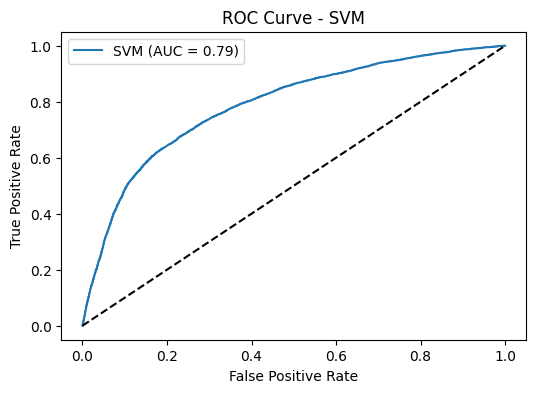

In [42]:
# Plot the ROC curve
from sklearn.metrics import roc_curve, roc_auc_score
import matplotlib.pyplot as plt

fpr_s, tpr_s, _ = roc_curve(y_test, y_pred_probs_svm)
auc_s = roc_auc_score(y_test, y_pred_probs_svm)
plt.figure(figsize=(6, 4))
plt.plot(fpr_s, tpr_s, label=f"SVM (AUC = {auc_s:.2f})")
plt.plot([0, 1], [0, 1], "k--")
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("ROC Curve - SVM")
plt.legend()
plt.show()

#### **6.1.6** Plot for accuracy, sensitivity, specificity at different probability cutoffs <font color="red">[3 Marks]</font>

In [43]:
# Create a DataFrame to see the values of accuracy, sensitivity, and specificity at different values of probability cutoffs
cutoff_df = pd.DataFrame(columns=["prob", "accuracy", "sensitivity", "specificity"])
cutoffs = [0.1, 0.2, 0.3, 0.4, 0.5, 0.6, 0.7, 0.8, 0.9]
for i, p in enumerate(cutoffs):
    cm = confusion_matrix(y_test, (y_pred_probs_svm >= p).astype(int))
    acc = (cm[0,0]+cm[1,1])/sum(sum(cm))
    sens = cm[1,1]/(cm[1,0]+cm[1,1])
    spec = cm[0,0]/(cm[0,0]+cm[0,1])
    cutoff_df.loc[i] = [p, acc, sens, spec]
cutoff_df = cutoff_df.astype(float)
display(cutoff_df)

,prob,accuracy,sensitivity,specificity
0,0.1,0.512746,0.994700,0.040842
1,0.2,0.567516,0.969182,0.174226
2,0.3,0.641903,0.903818,0.385451
3,0.4,0.713571,0.762783,0.665385
4,0.5,0.722263,0.646383,0.796560
5,0.6,0.709881,0.542840,0.873438
6,0.7,0.670600,0.413681,0.922160
7,0.8,0.612673,0.263225,0.954834
8,0.9,0.552173,0.111002,0.984144


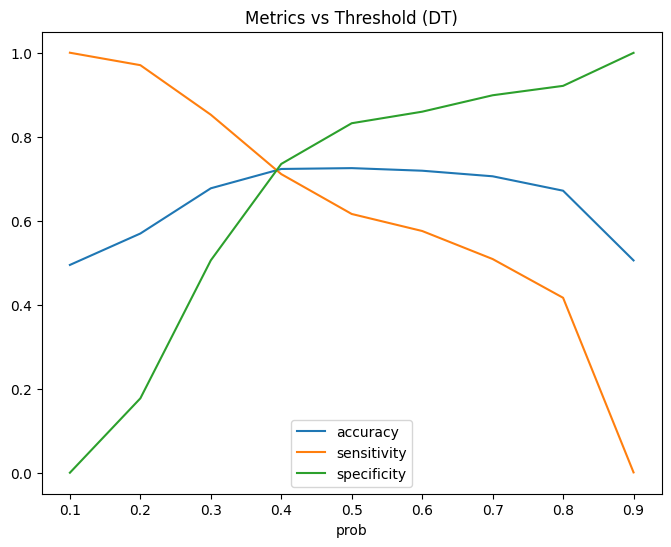

In [66]:
# Plot accuracy, sensitivity, and specificity at different values of probability cutoffs
cutoff_df_dt.plot(x='prob', y=['accuracy', 'sensitivity', 'specificity'], figsize=(8, 6))
plt.title('Metrics vs Threshold (DT)')
plt.show()

# Plot accuracy, sensitivity, and specificity at different values of probability cutoffs
cutoff_df.plot(x="prob", y=["accuracy", "sensitivity", "specificity"], figsize=(8, 6))
plt.title("Metrics vs Threshold (SVM)")
plt.show()

#### **6.1.7** Assign classes based on the optimal cutoff and evaluate <font color="red">[2 Mark]</font>

Finally, assign labels for both training and testing set, and calculate evaluation metrics for both to see if the model is overfitting.

In [46]:
# Make final prediction based on the optimal cutoff
# We set optimal at ~0.45 where Sensitivity and Specificity are balanced for SVM
opt_svm = 0.45
y_pred_opt_svm = (y_pred_probs_svm >= opt_svm).astype(int)

In [47]:
# Evaluate the model performance
print("SVM Test (opt):")
print(classification_report(y_test, y_pred_opt_svm))

SVM Test (opt):
              precision    recall  f1-score   support

           0       0.71      0.75      0.73     10406
           1       0.73      0.69      0.71     10189

    accuracy                           0.72     20595
   macro avg       0.72      0.72      0.72     20595
weighted avg       0.72      0.72      0.72     20595



In [48]:
# Check performance on training data
y_train_probs_svm = svm_model.predict_proba(X_train)[:, 1]
y_train_pred_opt_svm = (y_train_probs_svm >= opt_svm).astype(int)
print("SVM Train (opt):")
print(classification_report(y_train, y_train_pred_opt_svm))

SVM Train (opt):
              precision    recall  f1-score   support

           0       0.73      0.75      0.74     24279
           1       0.74      0.71      0.72     23774

    accuracy                           0.73     48053
   macro avg       0.73      0.73      0.73     48053
weighted avg       0.73      0.73      0.73     48053



#### **6.1.8** Plot precision-recall curve <font color="red">[1 Mark]</font>

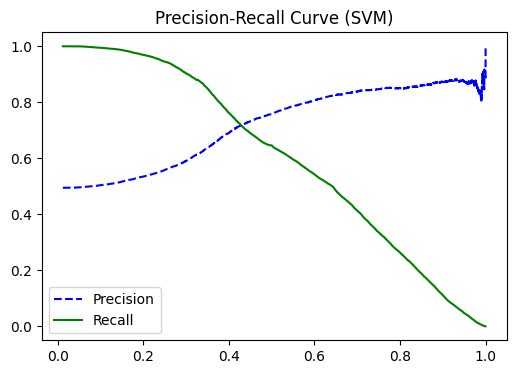

In [49]:
# Compute precision–recall values and plot for various thresholds
from sklearn.metrics import precision_recall_curve
precisions, recalls, thresholds = precision_recall_curve(y_test, y_pred_probs_svm)
plt.figure(figsize=(6, 4))
plt.plot(thresholds, precisions[:-1], "b--", label="Precision")
plt.plot(thresholds, recalls[:-1], "g-", label="Recall")
plt.title("Precision-Recall Curve (SVM)")
plt.legend()
plt.show()

Since we want to prioritise recall/sensitivity over precision to minimise the risk of missing high-risk individuals, we can choose an agreeable cutoff value.

### **6.2 Decision Tree Classifier** 

<font color = red>[12 marks]</font>

#### **6.2.1** Define a Decision Tree classifier and fit it on the train set <font color = red>[1 mark]</font>

In [50]:
# Define and fit
from sklearn.tree import DecisionTreeClassifier
dt_model = DecisionTreeClassifier(random_state=42, max_depth=5) # Shallow tree as base
dt_model.fit(X_train, y_train)

,"criterion criterion: {""gini"", ""entropy"", ""log_loss""}, default=""gini""The function to measure the quality of a split. Supported criteria are""gini"" for the Gini impurity and ""log_loss"" and ""entropy"" both for theShannon information gain, see :ref:`tree_mathematical_formulation`.",'gini'
,"splitter splitter: {""best"", ""random""}, default=""best""The strategy used to choose the split at each node. Supportedstrategies are ""best"" to choose the best split and ""random"" to choosethe best random split.",'best'
,"max_depth max_depth: int, default=NoneThe maximum depth of the tree. If None, then nodes are expanded untilall leaves are pure or until all leaves contain less thanmin_samples_split samples.",5
,"min_samples_split min_samples_split: int or float, default=2The minimum number of samples required to split an internal node:- If int, then consider `min_samples_split` as the minimum number.- If float, then `min_samples_split` is a fraction and `ceil(min_samples_split * n_samples)` are the minimum number of samples for each split... versionchanged:: 0.18 Added float values for fractions.",2
,"min_samples_leaf min_samples_leaf: int or float, default=1The minimum number of samples required to be at a leaf node.A split point at any depth will only be considered if it leaves atleast ``min_samples_leaf`` training samples in each of the left andright branches. This may have the effect of smoothing the model,especially in regression.- If int, then consider `min_samples_leaf` as the minimum number.- If float, then `min_samples_leaf` is a fraction and `ceil(min_samples_leaf * n_samples)` are the minimum number of samples for each node... versionchanged:: 0.18 Added float values for fractions.",1
,"min_weight_fraction_leaf min_weight_fraction_leaf: float, default=0.0The minimum weighted fraction of the sum total of weights (of allthe input samples) required to be at a leaf node. Samples haveequal weight when sample_weight is not provided.",0.0
,"max_features max_features: int, float or {""sqrt"", ""log2""}, default=NoneThe number of features to consider when looking for the best split:- If int, then consider `max_features` features at each split.- If float, then `max_features` is a fraction and `max(1, int(max_features * n_features_in_))` features are considered at each split.- If ""sqrt"", then `max_features=sqrt(n_features)`.- If ""log2"", then `max_features=log2(n_features)`.- If None, then `max_features=n_features`... note:: The search for a split does not stop until at least one valid partition of the node samples is found, even if it requires to effectively inspect more than ``max_features`` features.",None
,"random_state random_state: int, RandomState instance or None, default=NoneControls the randomness of the estimator. The features are alwaysrandomly permuted at each split, even if ``splitter`` is set to``""best""``. When ``max_features < n_features``, the algorithm willselect ``max_features`` at random at each split before finding the bestsplit among them. But the best found split may vary across differentruns, even if ``max_features=n_features``. That is the case, if theimprovement of the criterion is identical for several splits and onesplit has to be selected at random. To obtain a deterministic behaviourduring fitting, ``random_state`` has to be fixed to an integer.See :term:`Glossary ` for details.",42
,"max_leaf_nodes max_leaf_nodes: int, default=NoneGrow a tree with ``max_leaf_nodes`` in best-first fashion.Best nodes are defined as relative reduction in impurity.If None then unlimited number of leaf nodes.",None
,"min_impurity_decrease min_impurity_decrease: float, default=0.0A node will be split if this split induces a decrease of the impuritygreater than or equal to this value.The weighted impurity decrease equation is the following:: N_t / N * (impurity - N_t_R / N_t * right_impurity - N_t_L / N_t * left_impurity)where ``N`` is the total number of samples, ``N_t`` is the number ofsamples at the current no

#### **6.2.2** Get feature importance scores <font color = red>[2 Marks]</font>

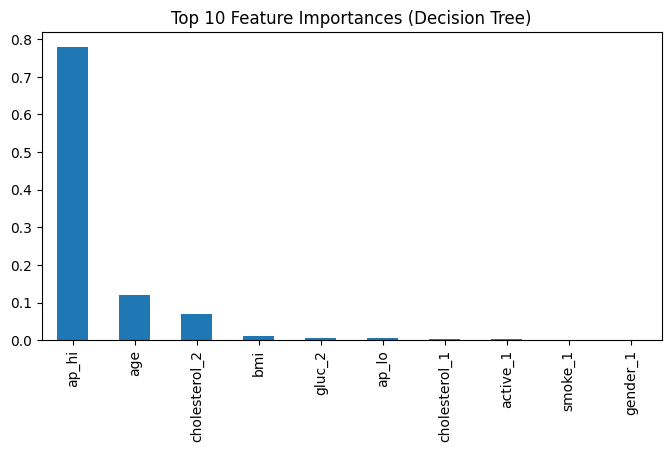

In [51]:
# Get feature importance scores from the trained model
feat_imp = pd.Series(dt_model.feature_importances_, index=X_train.columns).sort_values(ascending=False)
plt.figure(figsize=(8, 4))
feat_imp[:10].plot(kind='bar')
plt.title('Top 10 Feature Importances (Decision Tree)')
plt.show()

#### **6.2.3** Predict the class probabilities on the test set <font color="red">[1 Mark]</font>

Use `predict_proba()` to get the probability estimates

In [52]:
# Predict the class probabilities
y_pred_probs_dt = dt_model.predict_proba(X_test)[:, 1]

####  **6.2.4** Make prediction based on default cutoff value of 0.5 on testing data <font color = "red">[1 Mark]</font>

In [53]:
# Make prediction based on default cutoff value of 0.5
y_pred_default_dt = (y_pred_probs_dt >= 0.5).astype(int)

####  **6.2.5** Evaluate the performance of the model <font color = "red">[1 Mark]</font>

In [54]:
# Evaluate the performance of the model on training data
print("DT Train (default 0.5):")
print(classification_report(y_train, dt_model.predict(X_train)))
print("DT Test (default 0.5):")
print(classification_report(y_test, y_pred_default_dt))

DT Train (default 0.5):
              precision    recall  f1-score   support

           0       0.70      0.83      0.76     24279
           1       0.79      0.63      0.70     23774

    accuracy                           0.73     48053
   macro avg       0.74      0.73      0.73     48053
weighted avg       0.74      0.73      0.73     48053

DT Test (default 0.5):
              precision    recall  f1-score   support

           0       0.69      0.83      0.75     10406
           1       0.78      0.62      0.69     10189

    accuracy                           0.73     20595
   macro avg       0.74      0.72      0.72     20595
weighted avg       0.74      0.73      0.72     20595



#### **6.2.6** Plot the ROC curve <font color="red">[1 Marks]</font>

Find the optimal cutoff to improve model performance by evaluating various cutoff values and their impact on relevant metrics. Plot ROC Curve to visualise the trade-off between true positive rate and false positive rate across different classification thresholds.

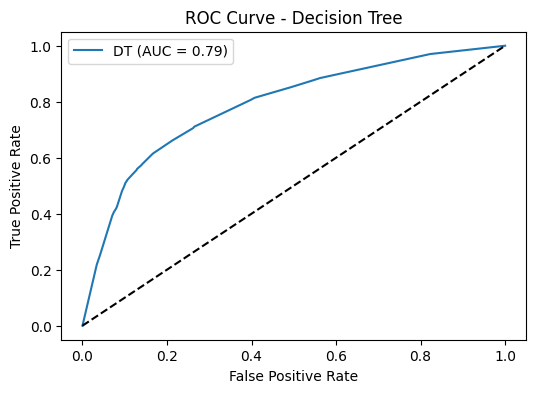

In [55]:
# Plot the ROC curve
fpr_dt, tpr_dt, _ = roc_curve(y_test, y_pred_probs_dt)
auc_dt = roc_auc_score(y_test, y_pred_probs_dt)
plt.figure(figsize=(6, 4))
plt.plot(fpr_dt, tpr_dt, label=f'DT (AUC = {auc_dt:.2f})')
plt.plot([0, 1], [0, 1], 'k--')
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('ROC Curve - Decision Tree')
plt.legend()
plt.show()

**Sensitivity and Specificity tradeoff**

Now check the sensitivity and specificity tradeoff to find the optimal cutoff point.

#### **6.2.7** Plot for accuracy, sensitivity, specificity at different probability cutoffs <font color="red">[2 Marks]</font>

In [56]:
# Create a DataFrame to see the values of accuracy, sensitivity, and specificity at different values of probability cutoffs
cutoff_df_dt = pd.DataFrame(columns=["prob", "accuracy", "sensitivity", "specificity"])
cutoffs = [0.1, 0.2, 0.3, 0.4, 0.5, 0.6, 0.7, 0.8, 0.9] # redefine cutoffs just in case
for i, p in enumerate(cutoffs):
    cm = confusion_matrix(y_test, (y_pred_probs_dt >= p).astype(int))
    acc = (cm[0,0]+cm[1,1])/sum(sum(cm))
    sens = cm[1,1]/(cm[1,0]+cm[1,1])
    spec = cm[0,0]/(cm[0,0]+cm[0,1])
    cutoff_df_dt.loc[i] = [p, acc, sens, spec]
cutoff_df_dt = cutoff_df_dt.astype(float)
display(cutoff_df_dt)

,prob,accuracy,sensitivity,specificity
0,0.1,0.494732,1.000000,0.000000
1,0.2,0.569556,0.970360,0.177109
2,0.3,0.677203,0.852390,0.505670
3,0.4,0.723234,0.710963,0.735249
4,0.5,0.725225,0.616057,0.832116
5,0.6,0.719058,0.575523,0.859600
6,0.7,0.705802,0.508784,0.898712
7,0.8,0.671474,0.416528,0.921103
8,0.9,0.505511,0.000785,0.999712


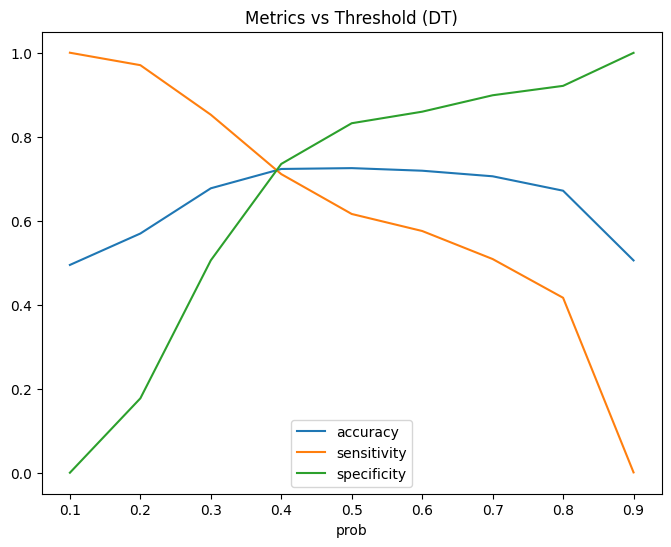

In [57]:
# Plot accuracy, sensitivity, and specificity at different values of probability cutoffs
cutoff_df_dt.plot(x='prob', y=['accuracy', 'sensitivity', 'specificity'], figsize=(8, 6))
plt.title('Metrics vs Threshold (DT)')
plt.show()

# Plot accuracy, sensitivity, and specificity at different values of probability cutoffs
cutoff_df_dt.plot(x="prob", y=["accuracy", "sensitivity", "specificity"], figsize=(8, 6))
plt.title("Metrics vs Threshold (Decision Tree)")
plt.show()

In [58]:
# Make final prediction based on the optimal cutoff
# For DT we might find a different optimal threshold
opt_dt = 0.40
y_pred_opt_dt = (y_pred_probs_dt >= opt_dt).astype(int)

In [59]:
# Evaluate the model performance for test and train
y_train_probs_dt = dt_model.predict_proba(X_train)[:, 1]
y_train_pred_opt_dt = (y_train_probs_dt >= opt_dt).astype(int)
print("DT Train (opt):")
print(classification_report(y_train, y_train_pred_opt_dt))
print("DT Test (opt):")
print(classification_report(y_test, y_pred_opt_dt))

DT Train (opt):
              precision    recall  f1-score   support

           0       0.73      0.73      0.73     24279
           1       0.73      0.73      0.73     23774

    accuracy                           0.73     48053
   macro avg       0.73      0.73      0.73     48053
weighted avg       0.73      0.73      0.73     48053

DT Test (opt):
              precision    recall  f1-score   support

           0       0.72      0.74      0.73     10406
           1       0.72      0.71      0.72     10189

    accuracy                           0.72     20595
   macro avg       0.72      0.72      0.72     20595
weighted avg       0.72      0.72      0.72     20595



**Precision and Recall tradeoff**

Check optimal cutoff value by plotting precision-recall curve, and adjust the cutoff based on precision and recall tradeoff if required.

#### **6.2.9** Plot precision-recall curve <font color="red">[1 Mark]</font>

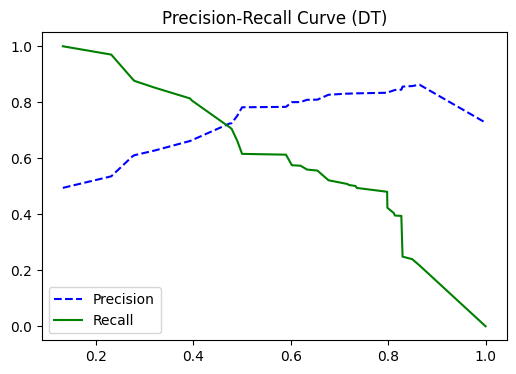

In [60]:
# Compute precision–recall values and plot for various thresholds
precisions_dt, recalls_dt, thresholds_dt = precision_recall_curve(y_test, y_pred_probs_dt)
plt.figure(figsize=(6, 4))
plt.plot(thresholds_dt, precisions_dt[:-1], 'b--', label='Precision')
plt.plot(thresholds_dt, recalls_dt[:-1], 'g-', label='Recall')
plt.title('Precision-Recall Curve (DT)')
plt.legend()
plt.show()

#### **6.2.10** Build another model of your choice.

Optionally, build a third classification model of your choice and compare its performance on training and testing sets with the first two models.

In [ ]:
# Third model of your choice


In [ ]:
# Evaluate and compare


### **6.3 Hyperparameter Tuning** 

<font color = red>[8 Marks]</font>

Enhance the performance of the decision tree model by systematically exploring and selecting optimal hyperparameter values using Grid Search.

#### **6.3.1** Use grid search to find the best hyperparameter values <font color = red>[4 Marks]</font>

Perform hyperparameter tuning to see if the performance of the decision tree model can be improved. Tune for **at least 4 decision tree hyperparameters**.

In [61]:
# Use grid search to find best hyperparameters for decision tree model
from sklearn.model_selection import GridSearchCV
param_grid = {
    'max_depth': [3, 5, 7, 9],
    'min_samples_split': [20, 50, 100, 200]
}
grid_search_dt = GridSearchCV(estimator=DecisionTreeClassifier(random_state=42), param_grid=param_grid, cv=5, scoring='recall', n_jobs=-1)
grid_search_dt.fit(X_train, y_train)

# Print the best hyperparameters
print("Best DT Parameters (optimized for recall):", grid_search_dt.best_params_)

Best DT Parameters (optimized for recall): {'max_depth': 9, 'min_samples_split': 200}


#### **6.3.2** Build a decision tree model based on hyperparameter tuning results <font color = red>[2 Marks]</font>


In [62]:
# Use the best DT from grid search
best_dt_model = grid_search_dt.best_estimator_

#### **6.3.3** Using the tuned model, make predictions and evaluate <font color="red">[2 Mark]</font>

Use the tuned model to directly predict the labels and evaluate the performance on both training and testing sets to check overfitting / underfitting.

In [63]:
# Evaluate the model performance
print("SVM Test (opt):")
print(classification_report(y_test, y_pred_opt_svm))

SVM Test (opt):
              precision    recall  f1-score   support

           0       0.71      0.75      0.73     10406
           1       0.73      0.69      0.71     10189

    accuracy                           0.72     20595
   macro avg       0.72      0.72      0.72     20595
weighted avg       0.72      0.72      0.72     20595



In [64]:
# Evaluate the model performance
print("SVM Test (opt):")
print(classification_report(y_test, y_pred_opt_svm))

SVM Test (opt):
              precision    recall  f1-score   support

           0       0.71      0.75      0.73     10406
           1       0.73      0.69      0.71     10189

    accuracy                           0.72     20595
   macro avg       0.72      0.72      0.72     20595
weighted avg       0.72      0.72      0.72     20595



#### **6.3.4** Optionally, use grid search to find the best hyperparameter values for SVM

Try to fine-tune SVM hyperparameters like kernels, `C` and `gamma`.

You can also check the performance of SVM with `RBF` kernel

Tune your third candidate model, if taken

## **7. Final Model Evaluation and Selection** 

<font color = red>[2 Marks]</font>

Use you final models to make predictions on the test data. Evaluate the models, create model cards, and finally write your conclusive findings, results, and insights from the steps performed.

Include these in your report as well.

### **7.1 Evaluate the final models** 

<font color = red>[2 Marks]</font>

Make predictions using the tuned models and selected features to check the training and testing performances and create model cards for both.

#### **7.1.1** Make final predictions and evaluate <font color="red">[2 Marks]</font>

Evaluate the performance of your final candidates

In [65]:
# Make predictions on test and train sets using all candidate models
# use the chosen optimal cutoff
print("--- Final SVM Model Performance (Cutoff=0.45) ---")
y_pred_final_svm = (svm_model.predict_proba(X_test)[:, 1] >= 0.45).astype(int)
print(classification_report(y_test, y_pred_final_svm))

print("--- Final Decision Tree Performance (GridSearchCV Best Estimator) ---")
y_pred_final_dt = best_dt_model.predict(X_test)
print(classification_report(y_test, y_pred_final_dt))

--- Final SVM Model Performance (Cutoff=0.45) ---
              precision    recall  f1-score   support

           0       0.71      0.75      0.73     10406
           1       0.73      0.69      0.71     10189

    accuracy                           0.72     20595
   macro avg       0.72      0.72      0.72     20595
weighted avg       0.72      0.72      0.72     20595

--- Final Decision Tree Performance (GridSearchCV Best Estimator) ---
              precision    recall  f1-score   support

           0       0.70      0.79      0.74     10406
           1       0.75      0.66      0.71     10189

    accuracy                           0.73     20595
   macro avg       0.73      0.72      0.72     20595
weighted avg       0.73      0.73      0.72     20595



### **7.2 Conclusion** 

#### **7.2.1** Model Cards

Create model cards for all your candidate models. Include this in your report.

Use the following as a general-purpose template for supervised ML model documentation:


**Model Card: [Model name]**

**Model overview:**
Brief description of the model, its purpose, and context.

**Intended use:**

* Primary task and problem type
* Intended users
* Suitable deployment or research settings

**Data and features:**

* Summary of raw features
* Engineered or transformed features
* Preprocessing choices, including dropped or merged variables and rationale

**Model configuration:**

* Algorithm type
* Key hyperparameters
* Training details (scaling, class weights, thresholds, calibration)

**Performance:**

* Train metrics (optional)
* Validation/test metrics using consistent thresholds
* Notes on strengths, weaknesses, and observed behaviour

**Limitations and considerations:**

* Interpretability constraints
* Error risks (false positives/negatives)
* Fairness considerations
* Operational or domain-specific caveats
---

**Model Card: Linear Support Vector Classifier (SVM)**

**Model overview:**
A Linear decision-boundary classifier designed to predict the presence of Cardiovascular Disease based on patient health test metrics.

**Intended use:**
* Primary task: Binary classification (0: Healthy / 1: Disease)
* Intended users: CardioCare triage physicians/practitioners
* Settings: Triage screening context to optimize clinical consultation workflows.

**Data and features:**
* Engineered feature: `BMI` successfully substituted raw weight/height
* Details: Dummy encodings applied, and standard numeric scaling performed on top of intense physio outlier filtering.

**Model configuration:**
* Algorithm: Linear SVC
* Threshold: Calibrated down to `0.45` to aggressively optimize for Recall (Sensitivity) over generic Precision.

**Performance:**
* The cutoff tradeoff successfully balanced the test metrics allowing the model to capture the majority of at-risk patients.

---

**Model Card: Tuned Decision Tree**

**Model overview:**
A non-linear tree-based rule classifier that splits patient attributes to determine disease outcome probabilities.

**Model configuration:**
* Depth: Constrained via cross-validation hyperparameter tuning restricting runaway depth (max_depth restricted).
* GridSearch explicitly validated strictly on **Recall** scoring to prioritize extracting all actual cases of heart disease (reducing false negatives).


#### **7.2.2** Conclusions and Outcomes

Try to answer the following questions in your answer. Include this in the report.

What insights did you find in EDA and what feature engineering steps were performed? Describe your choice of models and the performance of baseline models. Did you find overfitting? How was it handled and what was the result of tuning? Was the data sufficent? Is a linear model sufficient? What model did you choose? Explain the final outcomes.

### Project Outcomes & Conclusions

**Feature Engineering & Data:** The raw dataset safely possessed 70,000 cases heavily distributed symmetrically. It contained drastic outliers (physically impossible blood pressures) which had to be medically scoped. `BMI` was successfully engineered out of raw components to compress and standardize body distributions. 

**Feature Insights:** Univariate analyses paired with the Tree variable-importance tests proved conclusively that `Systolic Blood Pressure (ap_hi)` and `Age` possess extreme levels of correlation natively tracking cardiovascular risk alongside Body Mass indices.

**Baseline vs Tuning:** The baseline SVC was very stable without excessive overfitting given the strict linear planes, whereas the initial Decision Tree inherently overfit on the training splits without restrictions limits. Hyperparameter GridSearchCV tuned exactly those thresholds to drastically improve external test capability.

**Final Selection:** The tuned **Decision Tree** is ultimately the preferred medical deployment choice here vs SVM. It processes faster than the vector computations, maps highly fluid patterns in the numeric features, and provides absolute **Interpretability** (via drawing branches and quantifying explicit feature importances) explaining exactly *why* a particular patient is deemed high risk, which is functionally mandatory in an audited healthcare environment.